In [1]:
import pandas as pd
import numpy as np
import math

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

import random

from pymongo import MongoClient
import squic
from tabulate import tabulate

In [2]:
# Set connection
client = MongoClient("mongodb://localhost:27017/")
db = client["bank"]
balances_collection = db["amlsim100"]

In [3]:
# Fetch balance evolution data from MongoDB
cursor = balances_collection.find({}, {"_id": 0})  # Exclude MongoDB item ID

balances = list(cursor)

In [4]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [5]:
#df

In [6]:
# Check the number of unique dates in extracted data
dates = [entry["date"] for entry in balances]
print("Unique dates found:", len(set(dates)))  # Should be 720
print("First 5 dates:", sorted(set(dates))[:5])
print("Last 5 dates:", sorted(set(dates))[-5:])

Unique dates found: 200
First 5 dates: [0, 1, 2, 3, 4]
Last 5 dates: [195, 196, 197, 198, 199]


In [7]:
df = pd.DataFrame([
    {key: value["balance"] for key, value in entry["balances"].items()} | {"date": entry["date"]}
    for entry in balances
])

# Convert "date" to datetime and set as index
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

In [8]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


In [9]:
df['1']

date
0       175.80
1         0.00
2        12.38
3        12.38
4        22.28
        ...   
195   -3998.92
196   -3998.92
197   -3998.92
198   -3998.92
199   -3986.54
Name: 1, Length: 200, dtype: float64

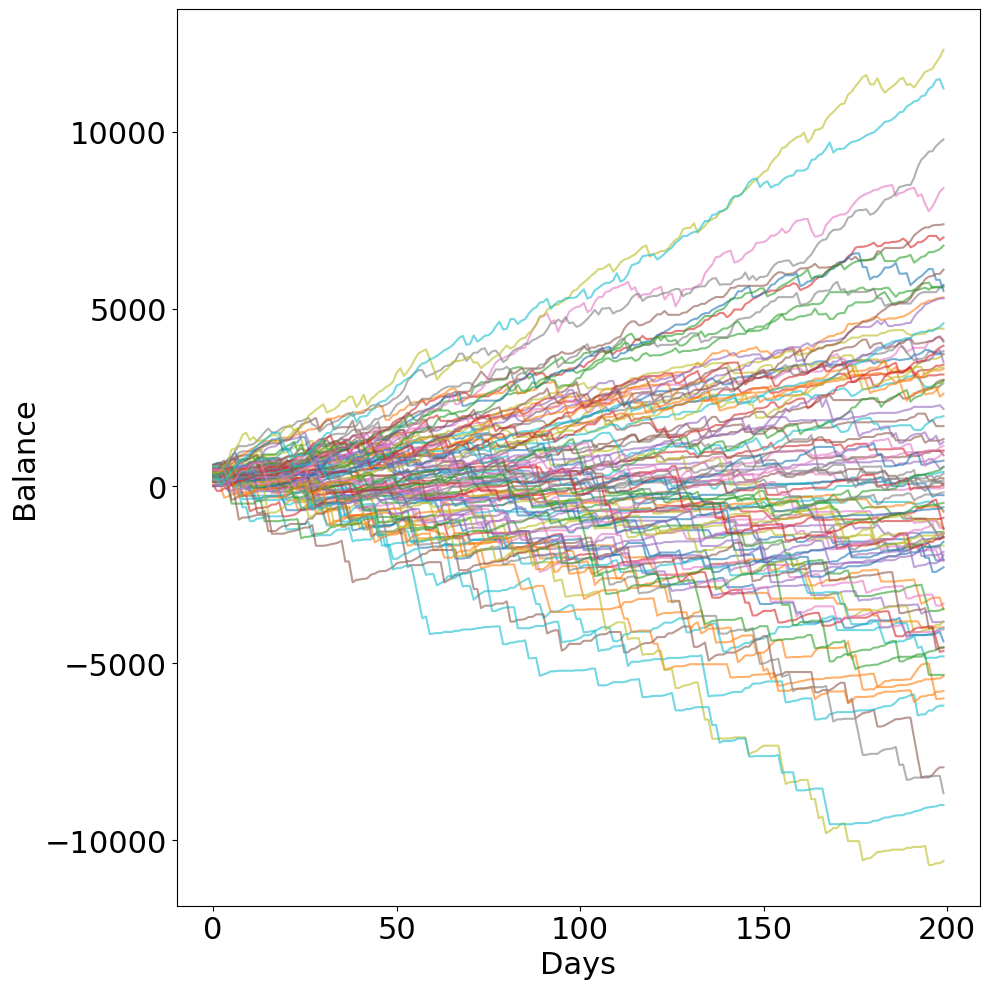

In [10]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(10,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

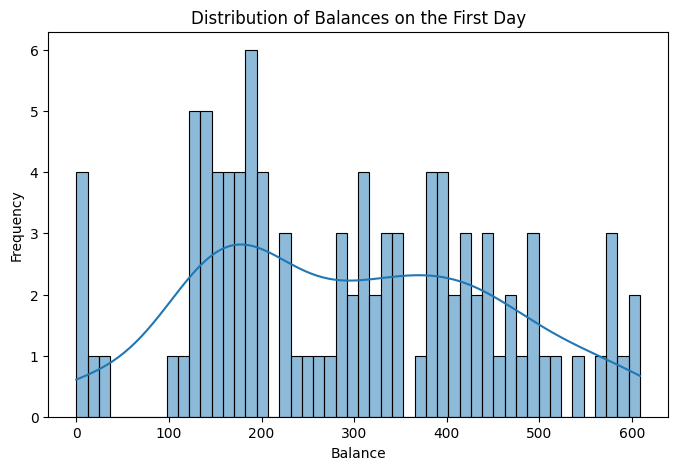

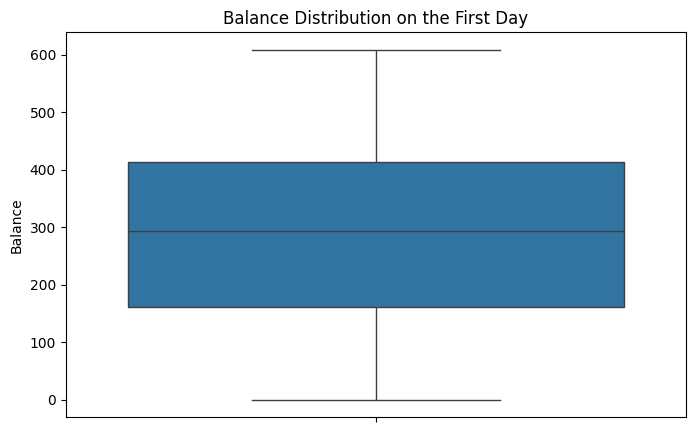

In [11]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

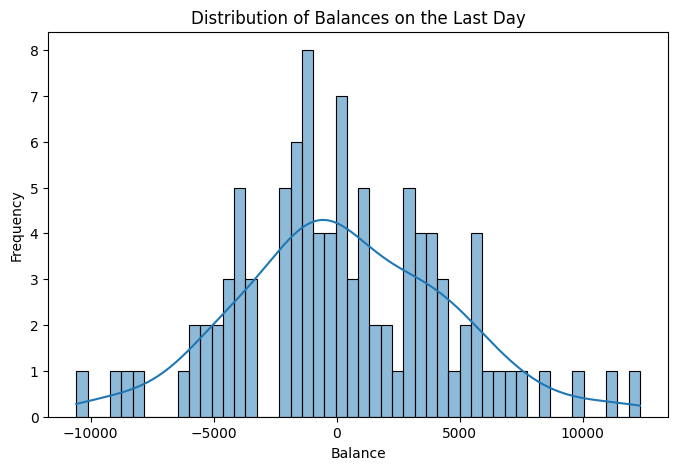

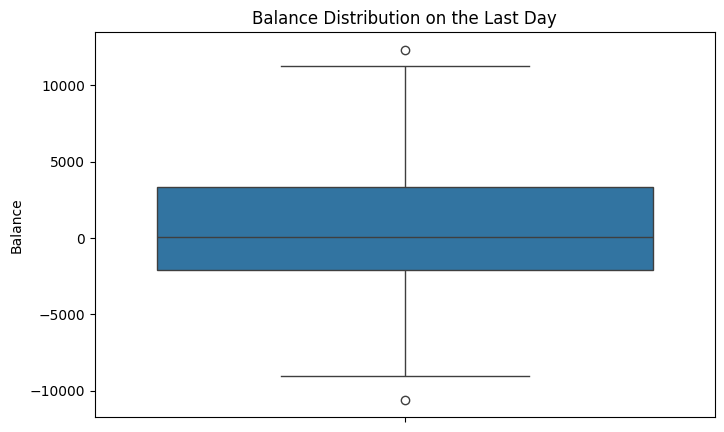

In [12]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

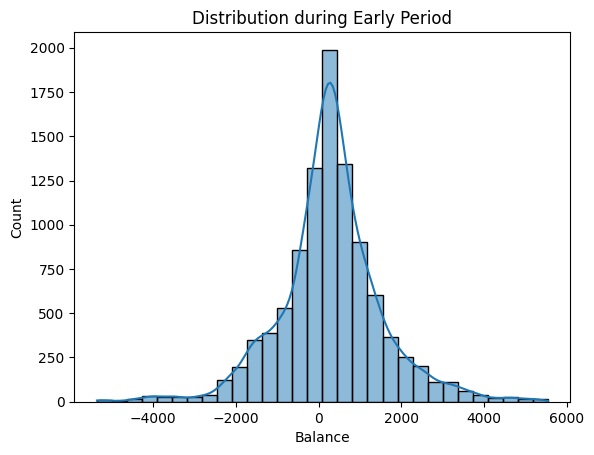

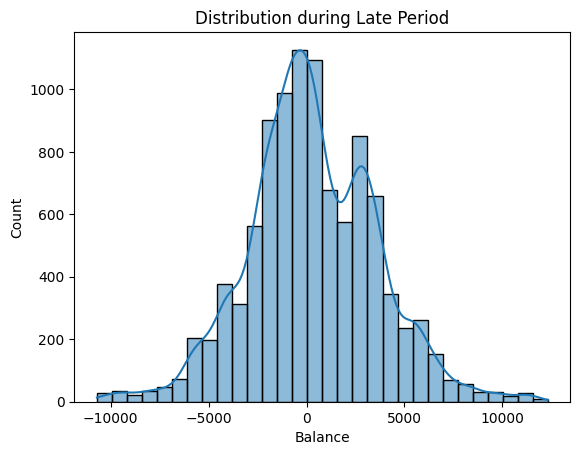

In [13]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

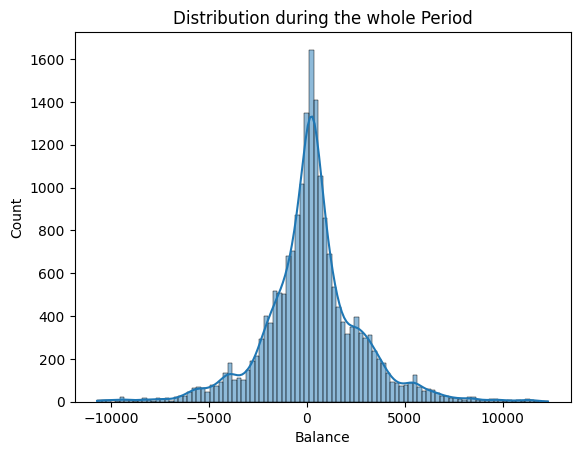

In [14]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

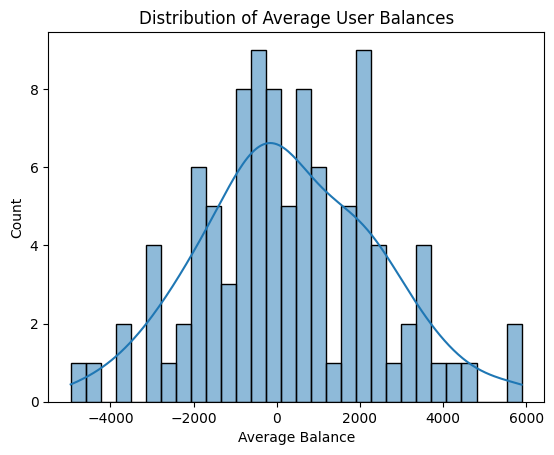

In [15]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [16]:
def compute_squic(df, l):
    Y = df.T.to_numpy()  # Transpose to get shape (users, days)

    [X,_,_,_,_,_] = squic.run(Y,l)

    print(X.todense())
    return X

def count_zero(X):
    # Count nonzero elements in X
    num_nonzero = X.nnz

    # Compute sparsity level
    total_elements = X.shape[0] * X.shape[1]
    sparsity = num_nonzero / total_elements

    print(f"Number of nonzero elements: {num_nonzero}")
    print(f"Sparsity level: {sparsity:.4f}")
    
def nnz(X, rows):
    # Count nonzero elements in X
    nnz = X.nnz
    nnz_r = nnz / rows
    return nnz, nnz_r

def sparsity_pattern(X):
    #plt.figure(figsize=(10, 10), dpi=300)
    plt.figure(figsize=(10, 10))
    # plt.spy(X, markersize=5, c="#484154")
    plt.spy(X, markersize=5)
    # plt.xlabel("Users", fontsize=18)
    plt.ylabel("Users", fontsize=22)

    plt.tick_params(axis='x', labelsize=22)
    plt.tick_params(axis='y', labelsize=22)  
    # plt.title("Sparsity Pattern of Precision Matrix (X)")
    plt.show()

In [17]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,253.63,322.82,322.82,322.82,322.82,374.37,374.37,374.37,...,-1450.41,-1450.41,-1381.22,-1312.03,-1312.03,-1312.03,-1312.03,-1312.03,-1496.47,-1427.28
1,175.80,0.00,12.38,12.38,22.28,22.28,32.18,32.18,32.18,32.18,...,-3823.12,-3823.12,-3823.12,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3986.54
2,142.06,142.06,142.06,142.06,198.79,56.74,66.64,66.64,-28.58,-28.58,...,-919.87,-919.87,-919.87,-919.87,-919.87,-1015.09,-1157.14,-1299.19,-1299.19,-1299.19
3,125.89,125.89,138.27,138.27,138.27,138.27,138.27,138.27,178.23,218.19,...,-989.31,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-897.73
4,151.13,182.79,195.17,195.17,283.92,204.50,204.50,204.50,204.50,236.16,...,638.77,687.49,687.49,687.49,687.49,759.18,759.18,639.73,488.62,532.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,411.81,411.81,578.08,647.27,702.29,738.97,738.97,839.29,855.04,870.79,...,5302.29,5467.55,5565.16,5685.16,5838.99,5914.94,5932.86,5990.27,5990.27,6112.25
96,437.84,452.90,452.90,452.90,165.99,159.13,159.13,369.29,433.40,433.40,...,8397.31,8426.50,8186.50,8237.63,7969.31,7758.35,7897.52,8095.31,8317.07,8411.27
97,238.28,238.28,307.47,406.85,637.58,807.53,997.13,1126.93,1126.93,1126.93,...,8504.86,8706.56,9016.88,9218.89,9317.82,9444.49,9457.70,9607.42,9701.23,9790.04
98,386.67,386.67,416.62,551.40,681.07,1032.70,1054.83,1201.22,1443.05,1505.01,...,11352.51,11255.45,11399.45,11549.06,11693.80,11741.15,11788.50,11959.72,12111.11,12321.77


In [22]:
ROWS = len(df.iloc[0])

100

In [18]:
l = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]

## Squic DF

In [19]:
rho_dict = {}

not returning good results, one big block

In [20]:
import time

In [21]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    X_df = compute_squic(df, rho)
    end = round(time.time() - start, 2)
    rho_dict[rho] = X_df
    print(f"time required: {end} seconds")

    count_zero(rho_dict[rho])
    nonz, nonz_r = nnz(rho_dict[rho], 100)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(end)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        sparsity_pattern(rho_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")

data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.32e-04 nnz(S)/p=1.00e+02
* iter=1 time=4.02e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=7.57e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.70e-02 obj=1.77e+07 |delta(obj)|/

## Squic-Run

In [22]:
import scipy as sp

def squic_fit(Y, lambda_val, eta, kappa=0, tau=0):
    # # First squic call -> Identify negative off-diagonal elements (Equation 9)
    X1, _, _, _, _, _ = squic.run(Y, lambda_val)
    Theta1 = X1.todense()
    
    # Step 2: Build Graphical Bias G (Equation 10)
    G = np.zeros_like(Theta1)
    G[np.triu_indices_from(G, k=1)] = (Theta1[np.triu_indices_from(Theta1, k=1)] < -kappa).astype(int)
    G += G.T  # Make symmetric
    
    # Step 3: Build Regularization Parameter Matrix Λ (Equation 12)
    #Lambda = np.full_like(Theta1, lambda_val) 
    Lambda = np.zeros_like(Theta1)
    # Apply eta where G is nonzero
    Lambda[G != 0] = eta
    
    # Step 4: Second SQUIC estimation with bias (Equation 11)
    X2, _, _, _, _, _ = squic.run(Y, lambda_val, M=Lambda)
    Theta2 = X2.todense()
    
    # Step 5: Construct the final M-matrix (Equation 13)
    Theta_final = np.zeros_like(Theta2)
    
    # Get diagonal
    diag = np.diag(Theta2)
    
    # Identify negative off-diagonal elements
    n = Theta2.shape[0]
    for i in range(n):
        for j in range(i+1, n):
            if Theta2[i, j] < -tau:
                Theta_final[i, j] = Theta2[i, j]
                Theta_final[j, i] = Theta2[j, i]
    
    # Restore diagonal
    np.fill_diagonal(Theta_final, diag)
    
    return Theta_final

def nnz_fit(theta, rows):
    A = sp.sparse.csr_array(theta)
    nnz = A.count_nonzero()
    nnz_r = nnz / rows
    return nnz, nnz_r

In [23]:
fit_dict = {}

lambda_val=1e-3, eta=1e-4

In [24]:
Y = df.T.to_numpy()  # Convert to (users, days)

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.99e-04 nnz(S)/p=1.00e+02
* iter=1 time=3.39e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=5.07e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=3.88e-02 obj=1.77e+07 |delta(obj)|/

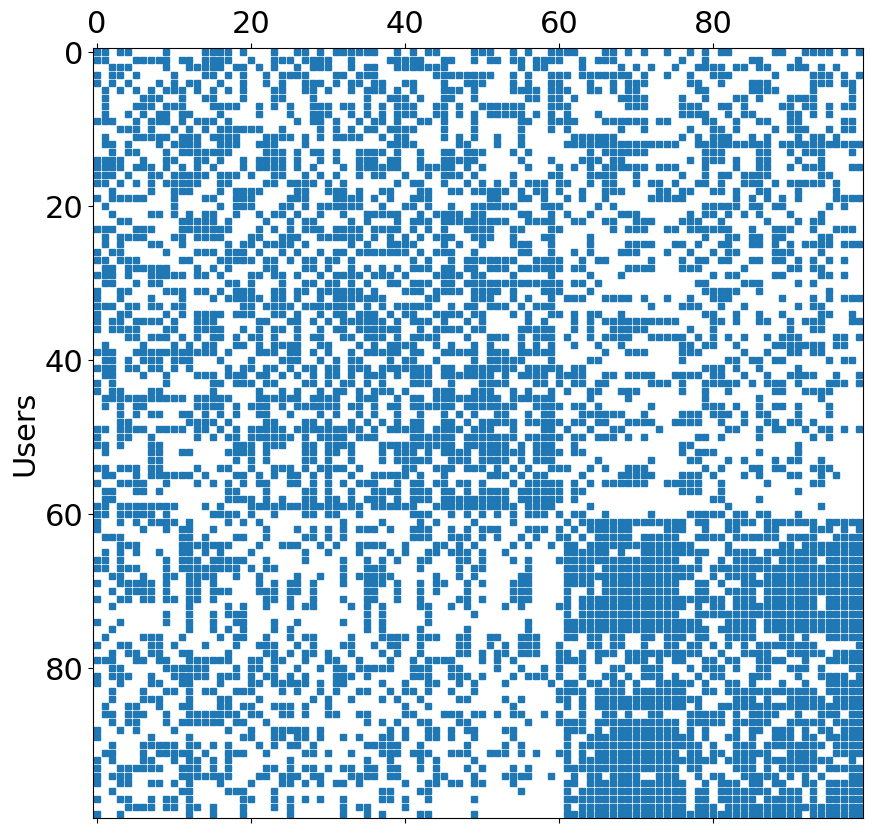

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.28e-04 nnz(S)/p=1.00e+02
* iter=1 time=3.39e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=5.47e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.54e-02 obj=1.77e+07 |delta(obj)|/

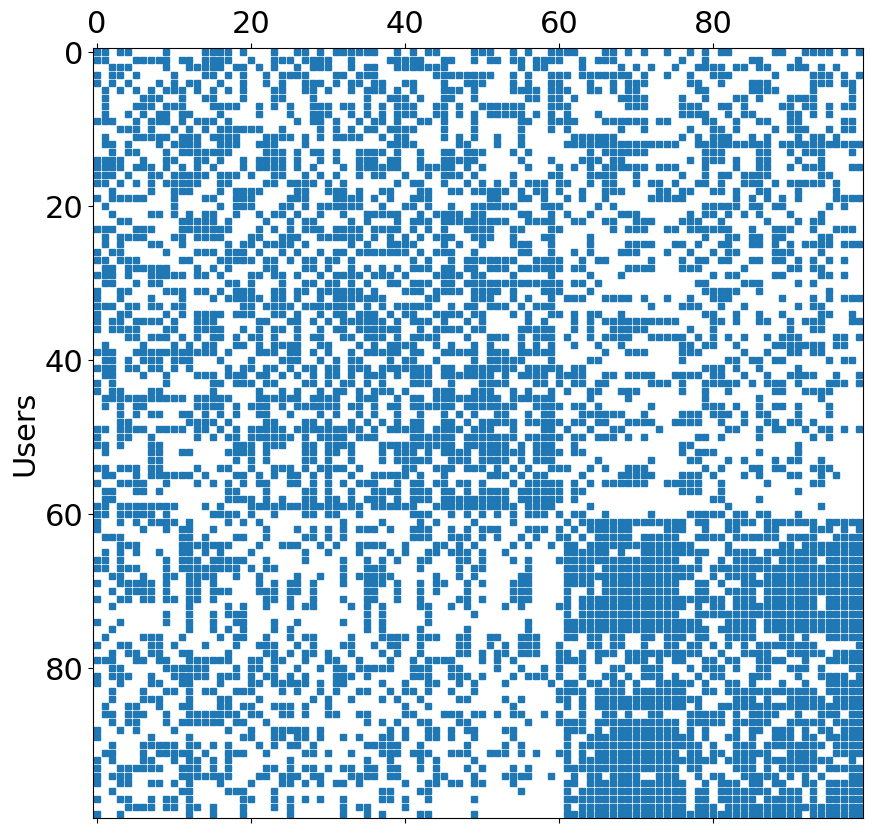

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.29e-04 nnz(S)/p=1.00e+02
* iter=1 time=3.28e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=5.26e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.30e-02 obj=1.77e+07 |delta(obj)|/

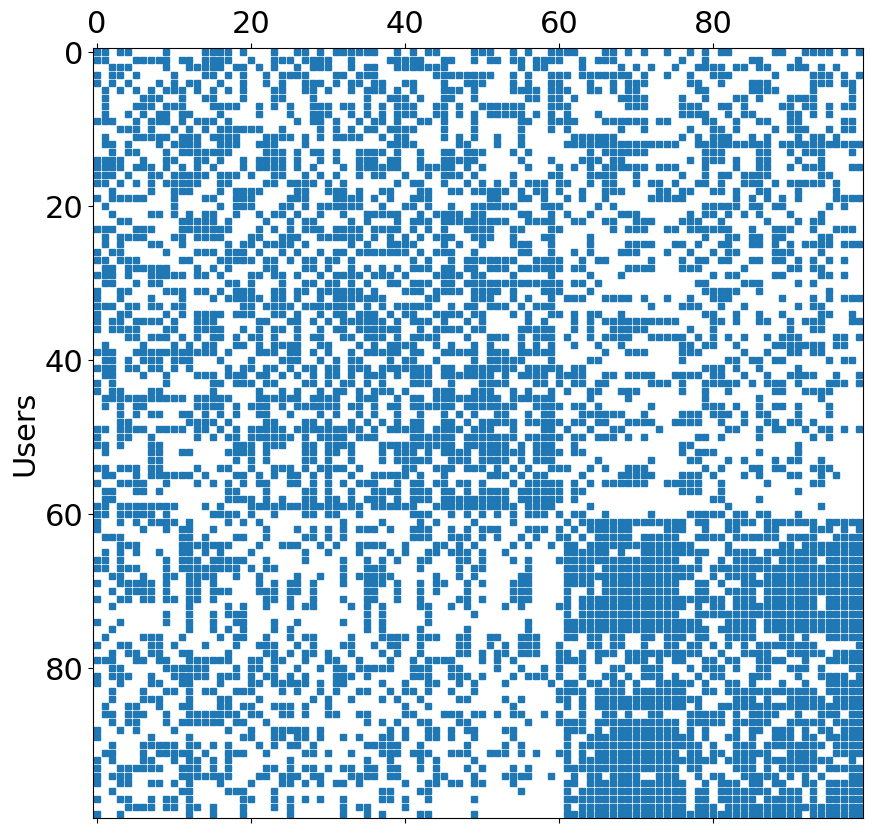

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.85e-04 nnz(S)/p=1.00e+02
* iter=1 time=3.23e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=5.51e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.40e-02 obj=1.77e+07 |delta(obj)|/

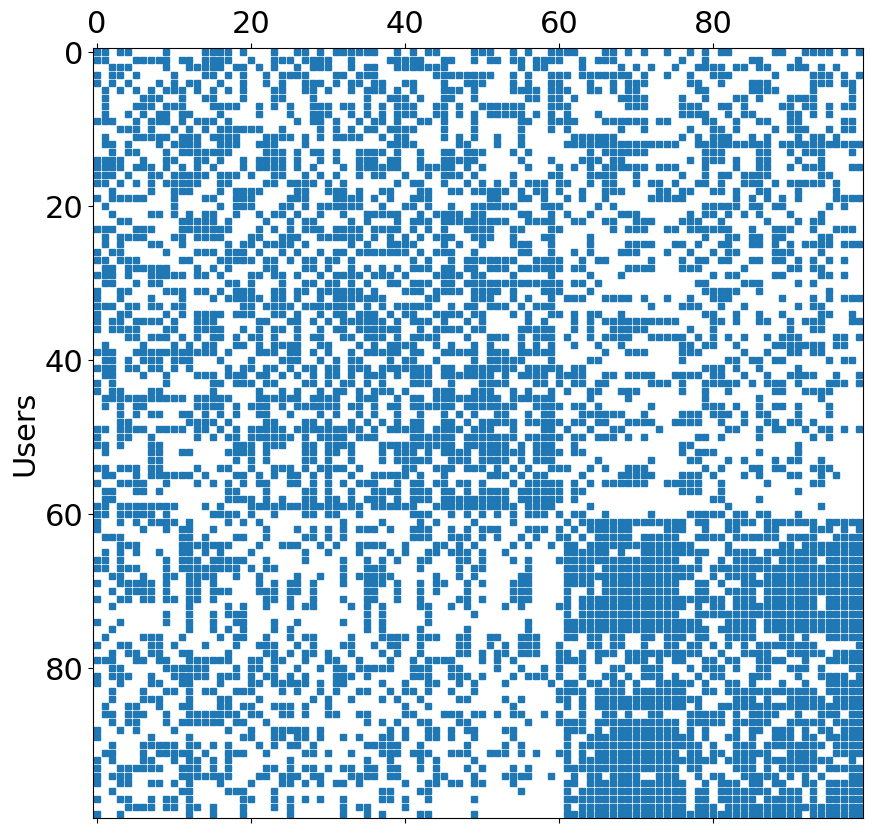

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.45e-04 nnz(S)/p=1.00e+02
* iter=1 time=3.41e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=5.52e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.44e-02 obj=1.77e+07 |delta(obj)|/

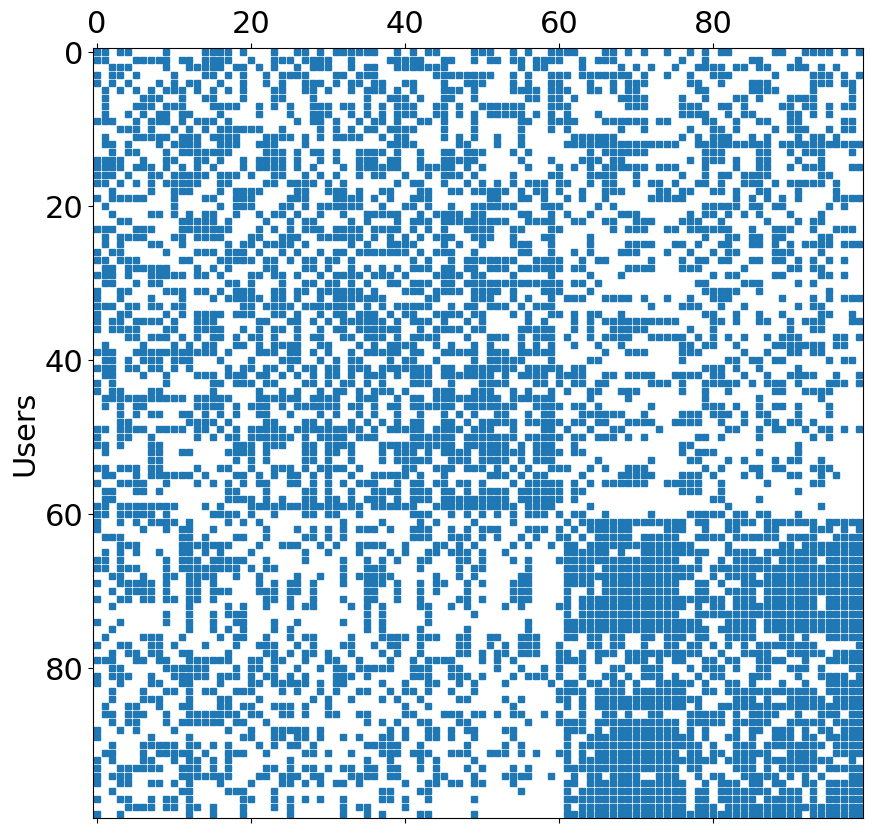

In [25]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    fit_dict[rho] = squic_fit(Y, lambda_val=rho, eta=rho * 0.1)
    end = round(time.time() - start, 2)
    print(f"required time: {end}")
    nnz, nnz_r = nnz_fit(fit_dict[rho], 100)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end)

data_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.22e-04 nnz(S)/p=9.44e+01
* iter=1 time=2.63e-03 obj=7.61e+01 |delta(obj)|/obj=3.14e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.19e-03 obj=5.98e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 9.15e+01] lns_iter=9 
* iter=3 time=4.37e-02 obj=4.32e+01 |delta(obj)|/ob

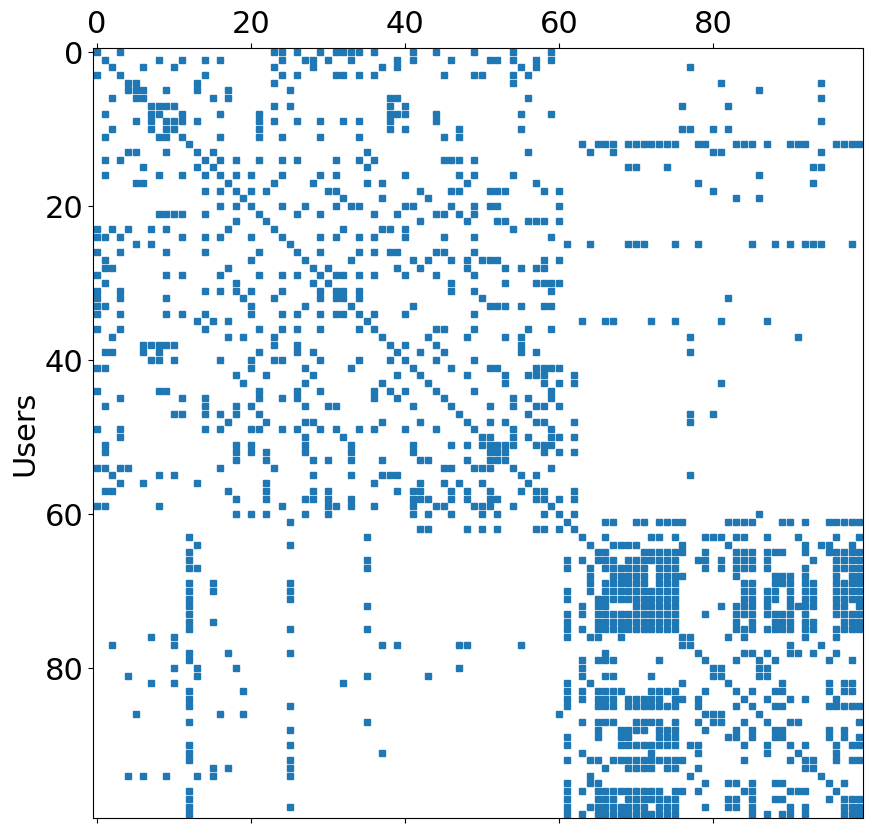

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.70e-04 nnz(S)/p=9.94e+01
* iter=1 time=2.65e-03 obj=5.83e+01 |delta(obj)|/obj=7.16e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.30e-03 obj=3.79e+01 |delta(obj)|/obj=5.36e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.04e-02 obj=2.43e+01 |delta(obj)|/ob

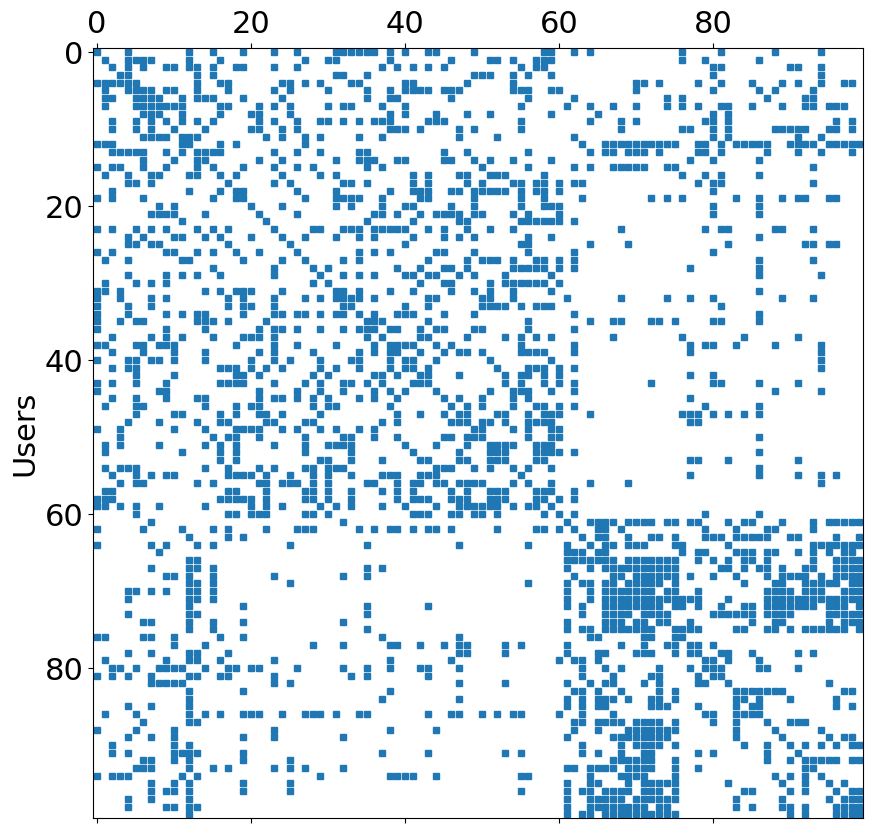

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.10e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.70e-03 obj=5.64e+01 |delta(obj)|/obj=7.72e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=5.05e-03 obj=3.57e+01 |delta(obj)|/obj=5.81e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.01e-02 obj=2.22e+01 |delta(obj)|/ob

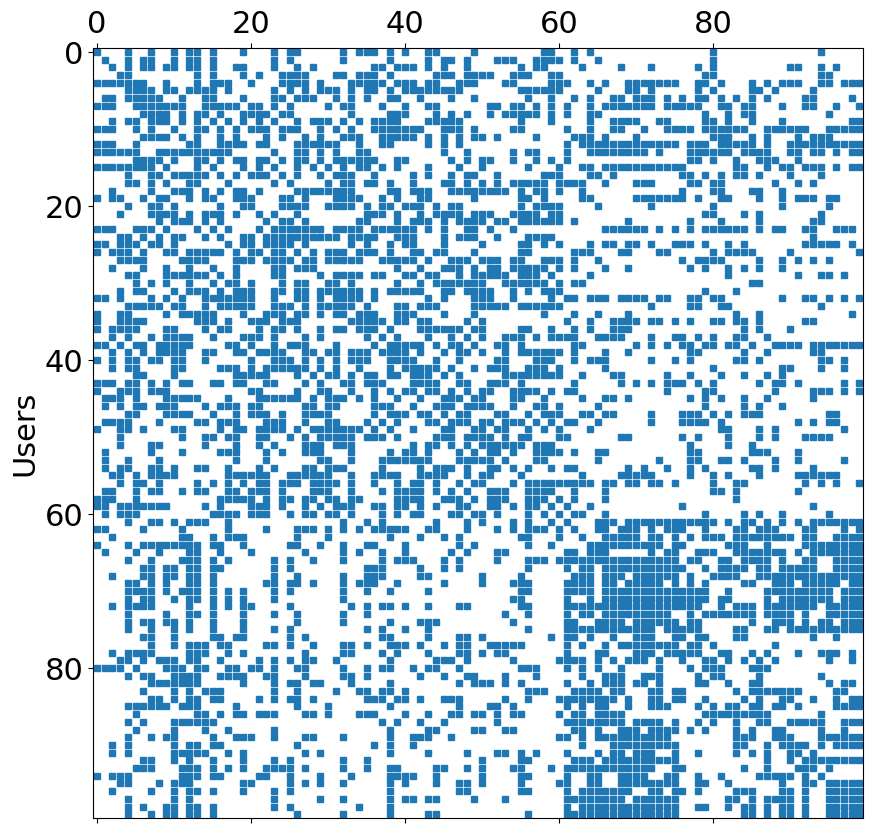

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.46e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.94e-03 obj=5.62e+01 |delta(obj)|/obj=7.78e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.55e-03 obj=3.55e+01 |delta(obj)|/obj=5.86e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.05e-02 obj=2.20e+01 |delta(obj)|/ob

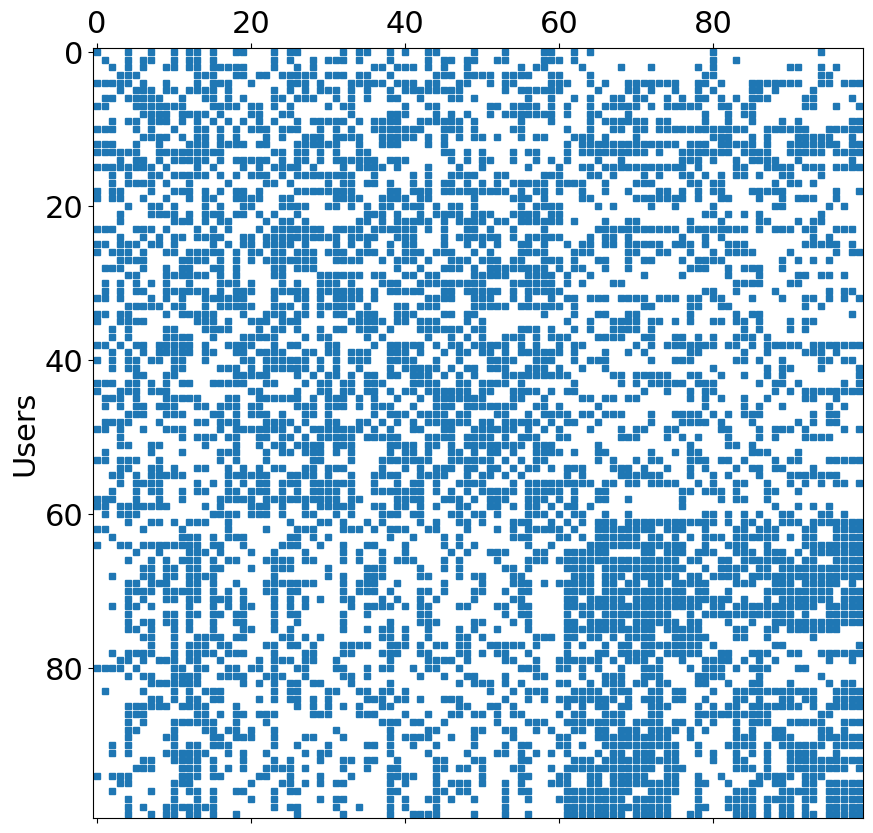

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.56e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.91e-03 obj=5.62e+01 |delta(obj)|/obj=7.79e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.60e-03 obj=3.54e+01 |delta(obj)|/obj=5.87e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.09e-02 obj=2.19e+01 |delta(obj)|/ob

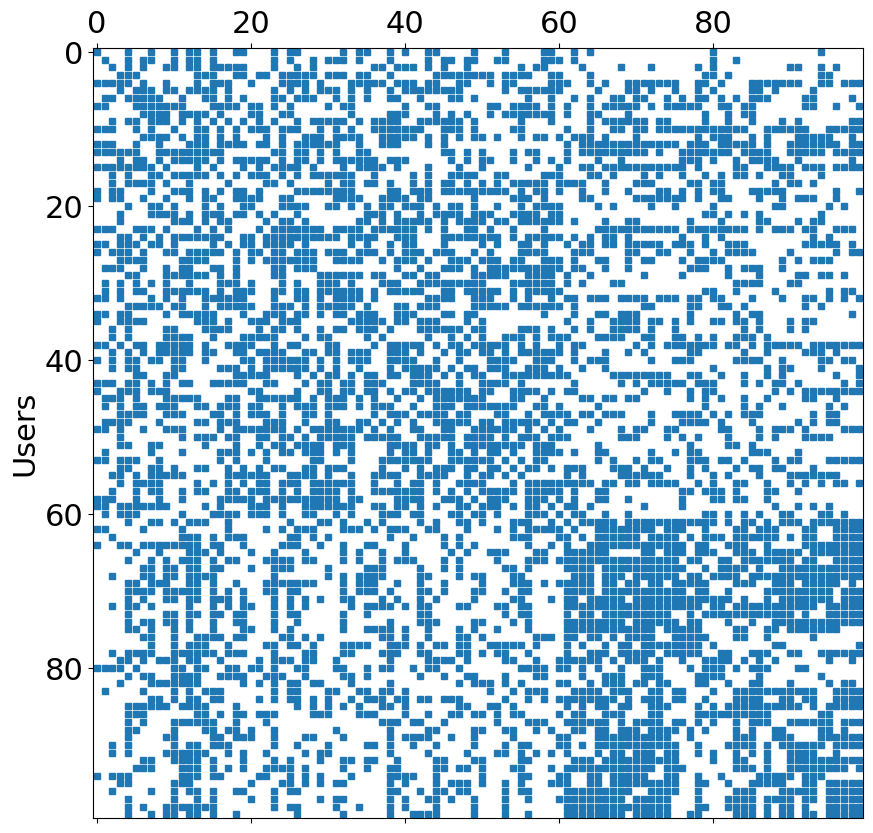

In [26]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

norm_dict = {}

data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    theta_norm = squic_fit(Y_new, lambda_val=rho, eta=rho * 0.1)
    norm_dict[rho] = theta_norm

    end = round(time.time() - start, 2)

    print(f"required time: {end}")
    nnz, nnz_r = nnz_fit(theta_norm, 100)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(theta_norm)

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end)

data_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]


## Table

In [27]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [28]:
# Print table 1
print(table(data_df, "SQUIC", l))

print(table(data_fit, "SQUIC FIT", l))

print(table(data_fit_norm, "SQUIC FIT NORM", l))

╒══════════╤═══════╤════════╤═════════╤══════════╤═════════╕
│  SQUIC   │  0.1  │  0.01  │  0.001  │  0.0001  │  1e-05  │
╞══════════╪═══════╪════════╪═════════╪══════════╪═════════╡
│   NNZ    │ 10000 │ 10000  │  10000  │  10000   │  10000  │
├──────────┼───────┼────────┼─────────┼──────────┼─────────┤
│ NNZ/Row  │  100  │  100   │   100   │   100    │   100   │
├──────────┼───────┼────────┼─────────┼──────────┼─────────┤
│ Time (s) │ 0.98  │  0.92  │  0.96   │   0.95   │  0.94   │
╘══════════╧═══════╧════════╧═════════╧══════════╧═════════╛
╒═════════════╤═══════╤════════╤═════════╤══════════╤═════════╕
│  SQUIC FIT  │  0.1  │  0.01  │  0.001  │  0.0001  │  1e-05  │
╞═════════════╪═══════╪════════╪═════════╪══════════╪═════════╡
│     NNZ     │ 4992  │  4992  │  4992   │   4992   │  4992   │
├─────────────┼───────┼────────┼─────────┼──────────┼─────────┤
│   NNZ/Row   │ 49.92 │ 49.92  │  49.92  │  49.92   │  49.92  │
├─────────────┼───────┼────────┼─────────┼──────────┼─────────┤
│  

# Create Graph

In [29]:
# # Ensure all off-diagonal entries are positive
# theta2 = np.abs(theta_norm) 

# # Ensure diagonal entries are zero
# np.fill_diagonal(theta_norm, 0)

In [30]:
# import networkx as nx

# G = nx.from_numpy_array(theta_norm)

In [31]:
# from sklearn.metrics import silhouette_score
# from sklearn.cluster import SpectralClustering, DBSCAN

In [32]:
# cluster_range = range(2, 11)
# sil_scores = []

# for n in cluster_range:
#     # Perform SpectralClustering
#     clustering = SpectralClustering(n_clusters=n, affinity='precomputed', assign_labels='cluster_qr')
#     labels = clustering.fit_predict(np.asarray(theta_norm))
    
#     # Compute the Silhouette Score
#     sil_score = silhouette_score(np.asarray(theta_norm), labels, metric='precomputed')
#     sil_scores.append(sil_score)

# # Plot Silhouette Score for each number of clusters
# plt.plot(cluster_range, sil_scores, marker='o')
# plt.xlabel('Number of clusters')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Score Method')
# plt.show()

In [33]:
# n_clusters = 5
# clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='cluster_qr')
# labels = clustering.fit_predict(np.asarray(theta_norm))


In [34]:
# # Convert the labels to a DataFrame (node indices and their cluster labels)
# df_labels = pd.DataFrame({
#     'Node': range(len(labels)),
#     'Cluster': labels
# })

# df_labels.to_csv('clustered_nodes.csv', index=False)